# Oil Spread Mean Reversion Strategy

A systematic, medium-frequency mean reversion strategy across oil market spread structures.

**Universe:** WTI (CL), Brent (BZ), Heating Oil (HO), RBOB Gasoline (RB) — front-month continuous futures
**Frequency:** Daily signals, 8–10 day average hold
**Spreads:** Crack spreads, location spread (WTI–Brent), butterflies, condors, outrights
**Signal:** Rolling z-score — enter when spread deviates beyond threshold, exit on reversion
**Data:** 2015–2025, live via yfinance

---

## Table of Contents
1. [Setup](#1-setup)
2. [Data](#2-data)
3. [Spread Construction](#3-spread-construction)
4. [Signal Generation](#4-signal-generation)
5. [Backtest](#5-backtest)
6. [Performance Metrics](#6-performance-metrics)
7. [Walk-Forward Analysis](#7-walk-forward-analysis)
8. [Key Findings](#8-key-findings)


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

# Project modules
from config   import (START_DATE, END_DATE, INITIAL_CAPITAL, SPREADS,
                      DEFAULT_LOOKBACK, DEFAULT_Z_ENTRY, DEFAULT_Z_EXIT)
from data     import fetch_all
from spreads  import build_all_spreads, spread_descriptive_stats
from signals  import compute_signals, zscore_heatmap_data
from backtest import run_backtest
from metrics  import portfolio_stats, per_spread_stats, monthly_returns, sharpe_float
from walk_forward import run_walk_forward, print_fold_summary

# Plot style
DARK  = "#0d1117"; PANEL = "#161b22"; GRID = "#21262d"
TEXT  = "#c9d1d9"; GREEN = "#3fb950"; RED  = "#f85149"
BLUE  = "#58a6ff"; GOLD  = "#d29922"; PURPLE = "#bc8cff"

plt.rcParams.update({
    "figure.facecolor": DARK, "axes.facecolor": PANEL,
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "grid.color": GRID,
    "grid.linewidth": 0.4, "axes.grid": True,
})

print("Setup complete.")


Setup complete.


## 2. Data

Four front-month continuous futures downloaded via yfinance. HO and RB are quoted in \$/gallon
and converted to \$/barrel (×42) so all spreads share the same unit.


In [2]:
print(f"Fetching {START_DATE} → {END_DATE}...")
prices = fetch_all(START_DATE, END_DATE)

summary = pd.DataFrame({
    k: {"bars": len(v), "start": v.index[0].date(), "end": v.index[-1].date(),
        "mean ($/bbl)": round(v.mean(), 2), "min": round(v.min(), 2), "max": round(v.max(), 2)}
    for k, v in prices.items()
}).T

print(summary.to_string())


Fetching 2015-01-01 → 2025-01-01...
  CL (CL=F): 2,514 bars
  BZ (BZ=F): 2,515 bars
  HO (HO=F): 2,515 bars
  RB (RB=F): 2,515 bars
    bars       start         end mean ($/bbl)    min     max
CL  2514  2015-01-02  2024-12-31         62.0 -37.63   123.7
BZ  2514  2015-01-02  2024-12-31        66.42  19.33  127.98
HO  2514  2015-01-02  2024-12-31        87.51  25.64  215.69
RB  2514  2015-01-02  2024-12-31        81.34   17.3   179.6


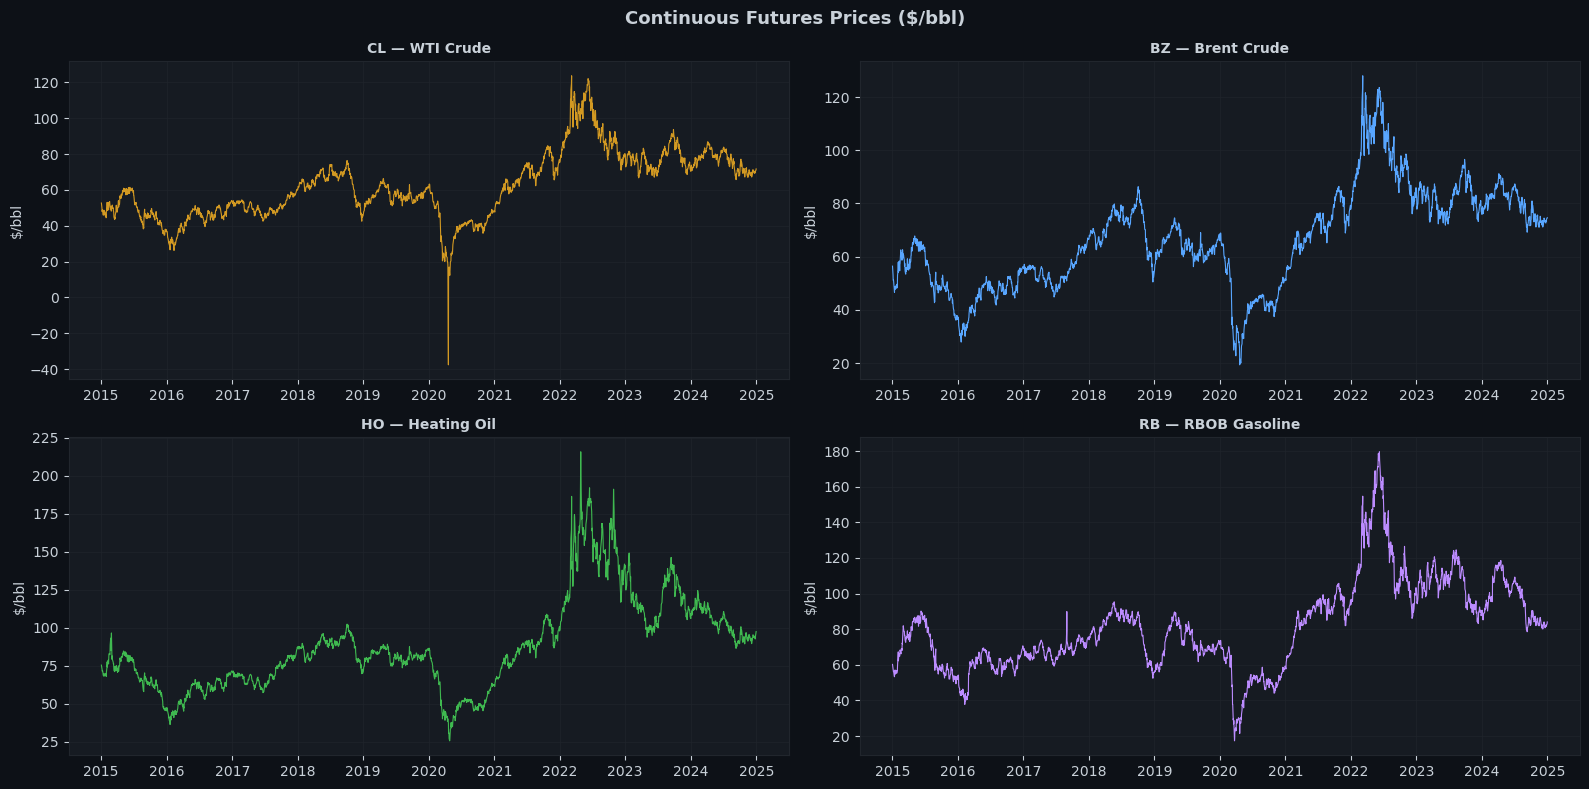

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), facecolor=DARK)
fig.suptitle("Continuous Futures Prices ($/bbl)", color=TEXT, fontsize=13, fontweight="bold")
labels = {"CL": "WTI Crude", "BZ": "Brent Crude", "HO": "Heating Oil", "RB": "RBOB Gasoline"}
colors = [GOLD, BLUE, GREEN, PURPLE]

for ax, (key, series), color in zip(axes.flat, prices.items(), colors):
    ax.plot(series.index, series, color=color, lw=0.8)
    ax.set_title(f"{key} — {labels[key]}", color=TEXT, fontsize=10, fontweight="bold")
    ax.set_ylabel("$/bbl")

plt.tight_layout()
plt.show()


## 3. Spread Construction

Each spread is a linear combination of the component prices, normalised to \$/barrel.

| Category | Logic |
|---|---|
| **Crack** | Refinery margin: product revenue minus crude cost |
| **Location** | WTI − Brent: pipeline/quality differential |
| **Butterfly** | Middle leg vs wings across 3 products |
| **Condor** | Two crack spreads traded against each other |
| **Outright** | Single commodity — secondary alpha source |

The **half-life** (Ornstein-Uhlenbeck fit) tells us how many days the spread takes to mean-revert
halfway. A half-life well below the lookback window confirms genuine mean-reversion.


In [4]:
spreads_df = build_all_spreads(prices)
print(f"Spreads built: {list(spreads_df.columns)}")
print(f"Shape: {spreads_df.shape}")
spreads_df.tail(3)


Spreads built: ['crack_321', 'crack_211', 'crack_ho', 'crack_rb', 'wti_brent', 'ho_rb', 'fly_wti_bz_ho', 'fly_rb_cl_ho', 'condor_rb_cl_ho_bz', 'outright_cl', 'outright_bz']
Shape: (2514, 11)


,crack_321,crack_211,crack_ho,crack_rb,wti_brent,ho_rb,fly_wti_bz_ho,fly_rb_cl_ho,condor_rb_cl_ho_bz,outright_cl,outright_bz
Date,,,,,,,,,,,
2024-12-27,15.656802,17.663003,23.681605,11.644401,-3.570000,12.037205,8.270803,17.663003,-4.233603,70.599998,74.169998
2024-12-30,16.539402,18.801802,25.589002,12.014602,-3.400002,13.574399,9.394499,18.801802,-5.087199,70.989998,74.389999
2024-12-31,16.810396,19.044097,25.745200,12.342994,-2.919998,13.402206,9.952602,19.044097,-5.241104,71.720001,74.639999


In [5]:
stats = spread_descriptive_stats(spreads_df)
print("Spread Descriptive Statistics:")
print(stats.to_string())


Spread Descriptive Statistics:
                      mean     std     min      max   skew     kurt  half_life_days
crack_321           21.393   9.380   2.396   68.772  1.514    2.793            31.1
crack_211           22.421  10.195   6.313   76.055  1.616    2.971            35.6
crack_ho            25.505  14.130   5.027  110.327  1.831    3.791            47.4
crack_rb            19.336   8.941  -6.064   65.699  1.259    2.345            25.4
wti_brent           -4.417   2.604 -63.200    1.000 -5.058  102.483             3.5
ho_rb                6.168  11.976 -16.061   69.014  1.601    3.221            47.2
fly_wti_bz_ho        8.335   6.672 -25.741   52.933  1.978    4.646            40.4
fly_rb_cl_ho        22.421  10.195   6.313   76.055  1.616    2.971            35.6
condor_rb_cl_ho_bz  -0.876   5.719 -33.157   26.991 -1.602    3.748            27.0
outright_cl         62.001  18.116 -37.630  123.700  0.369    0.528            97.5
outright_bz         66.419  18.449  19.330  1

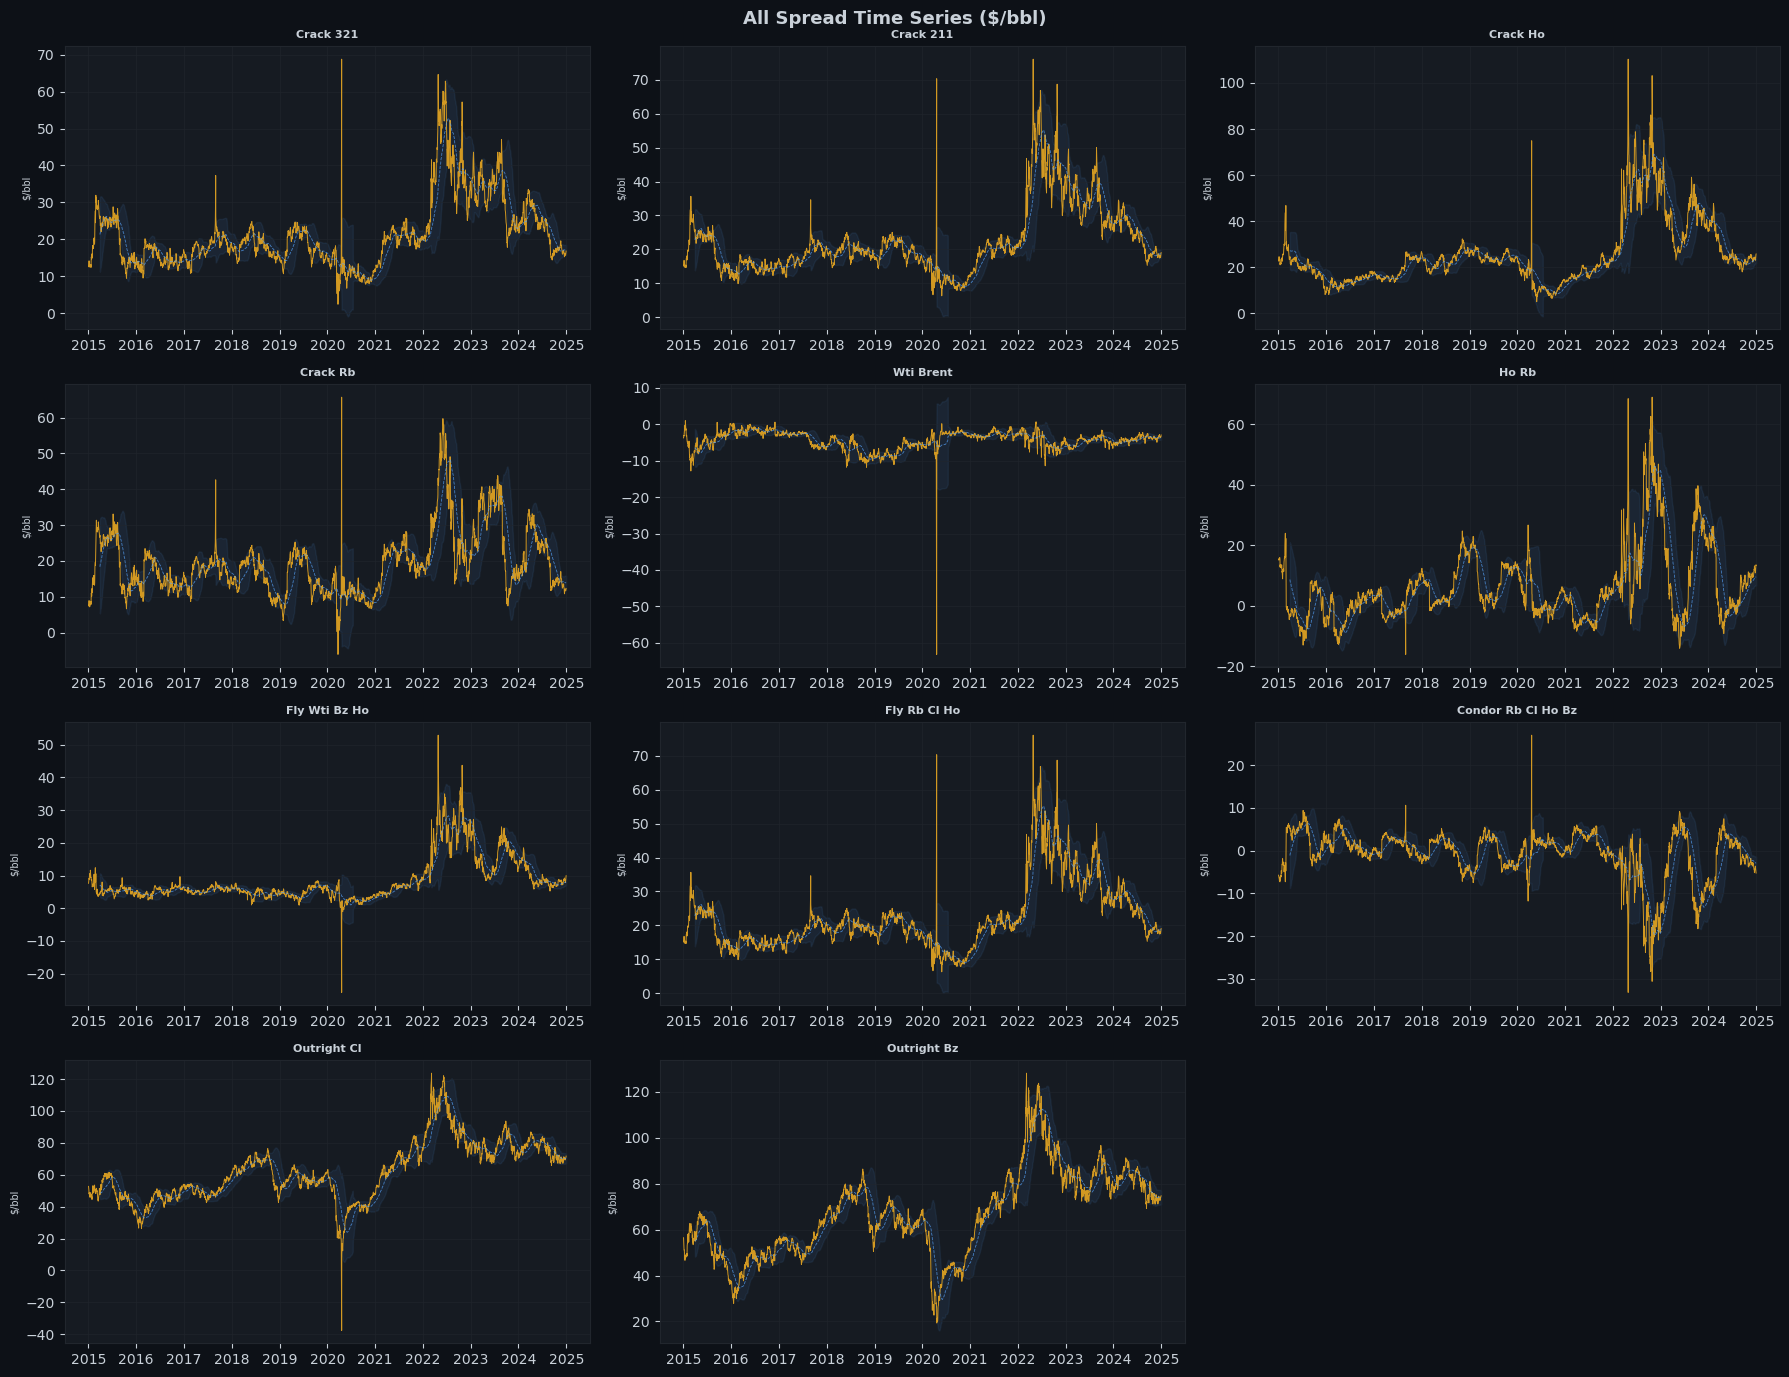

In [6]:
# Visualise all spread time series
n = len(spreads_df.columns)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 3.5), facecolor=DARK)
fig.suptitle("All Spread Time Series ($/bbl)", color=TEXT, fontsize=13, fontweight="bold")

for ax, col in zip(axes.flat, spreads_df.columns):
    s = spreads_df[col]
    mu = s.rolling(60).mean()
    std = s.rolling(60).std()
    ax.plot(s.index, s, color=GOLD, lw=0.7)
    ax.plot(mu.index, mu, color=BLUE, lw=0.6, ls="--", alpha=0.7)
    ax.fill_between(s.index, mu - 1.5*std, mu + 1.5*std, color=BLUE, alpha=0.08)
    ax.set_title(col.replace("_", " ").title(), color=TEXT, fontsize=8, fontweight="bold")
    ax.set_ylabel("$/bbl", fontsize=7)

for ax in axes.flat[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## 4. Signal Generation

For each spread, a rolling z-score is computed over a lookback window `w`:

$$z(t) = \frac{S(t) - \mu_{w}(t)}{\sigma_{w}(t)}$$

**Trading rules:**
- **Long spread** when $z < -z_{\text{entry}}$ — spread abnormally cheap, expect reversion up
- **Short spread** when $z > +z_{\text{entry}}$ — spread abnormally expensive, expect reversion down
- **Exit** when $|z| < z_{\text{exit}}$ — mean reversion achieved
- **Hard stop** at $2 \times \text{ATR}_{14}$ from entry price


In [7]:
signals = compute_signals(spreads_df)

# Summary of signal activity per spread
sig_summary = []
for name, ss in signals.items():
    sig = ss.signal
    sig_summary.append({
        "spread":    name,
        "lookback":  ss.lookback,
        "z_entry":   ss.z_entry,
        "long_pct":  f"{(sig == 1).mean():.1%}",
        "short_pct": f"{(sig == -1).mean():.1%}",
        "flat_pct":  f"{(sig == 0).mean():.1%}",
    })

pd.DataFrame(sig_summary)


,spread,lookback,z_entry,long_pct,short_pct,flat_pct
0,crack_321,40,1.50,31.7%,28.5%,39.8%
1,crack_211,40,1.50,29.1%,28.2%,42.7%
2,crack_ho,30,1.50,27.4%,32.7%,39.9%
3,crack_rb,30,1.50,29.8%,30.5%,39.7%
4,wti_brent,60,1.50,24.2%,26.3%,49.5%
5,ho_rb,30,1.50,31.7%,34.7%,33.5%
6,fly_wti_bz_ho,60,1.75,28.6%,26.8%,44.6%
7,fly_rb_cl_ho,40,1.75,23.9%,24.8%,51.4%
8,condor_rb_cl_ho_bz,60,2.00,27.6%,27.0%,45.3%
9,outright_cl,20,1.50,28.0%,36.6%,35.4%


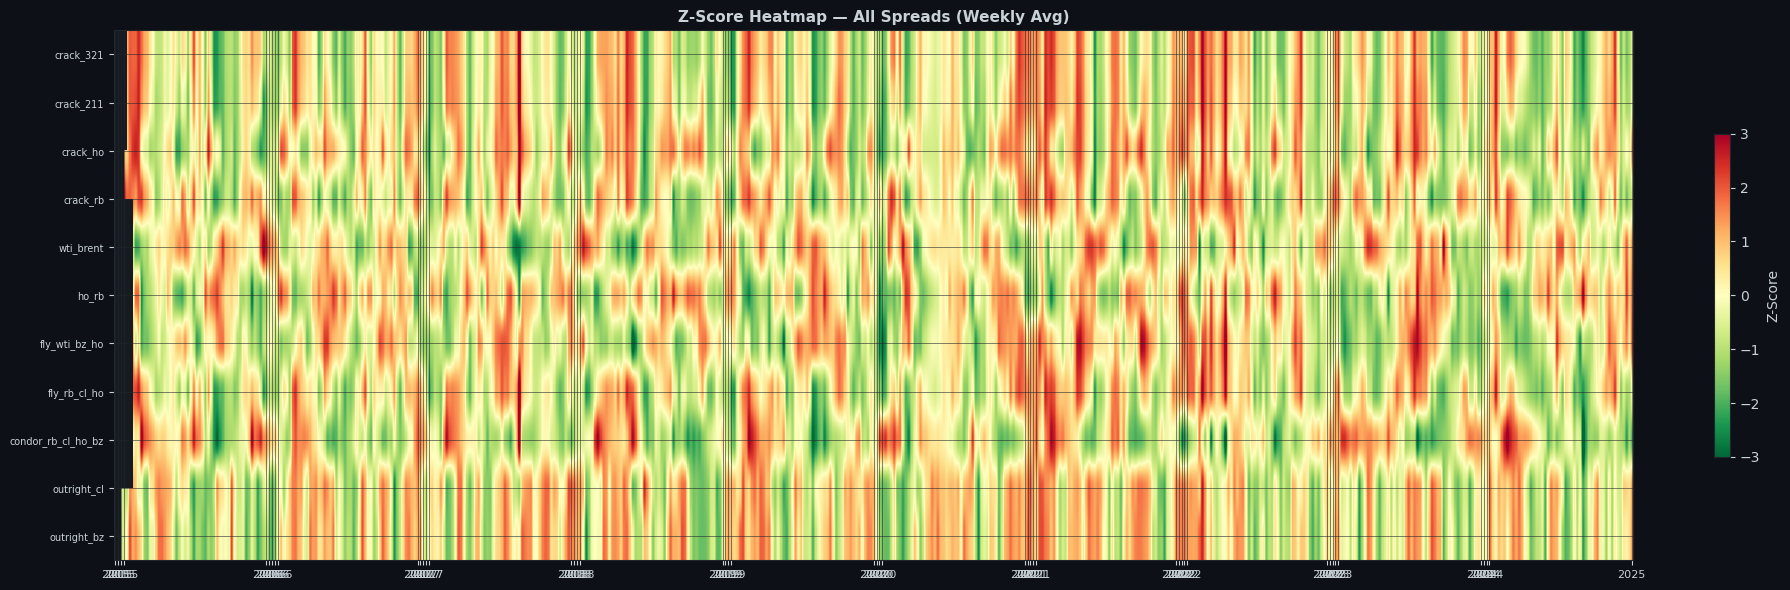

In [8]:
# Z-score heatmap across all spreads (weekly average)
zm = zscore_heatmap_data(signals)
zm_w = zm.resample("W").mean()

fig, ax = plt.subplots(figsize=(18, 6), facecolor=DARK)
im = ax.imshow(zm_w.T, aspect="auto", cmap="RdYlGn_r", vmin=-3, vmax=3)
ax.set_yticks(range(len(zm_w.columns)))
ax.set_yticklabels(zm_w.columns, fontsize=7)
xticks = [i for i, d in enumerate(zm_w.index) if d.month == 1]
ax.set_xticks(xticks)
ax.set_xticklabels([zm_w.index[i].year for i in xticks], fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.01, label="Z-Score")
ax.set_title("Z-Score Heatmap — All Spreads (Weekly Avg)", color=TEXT,
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


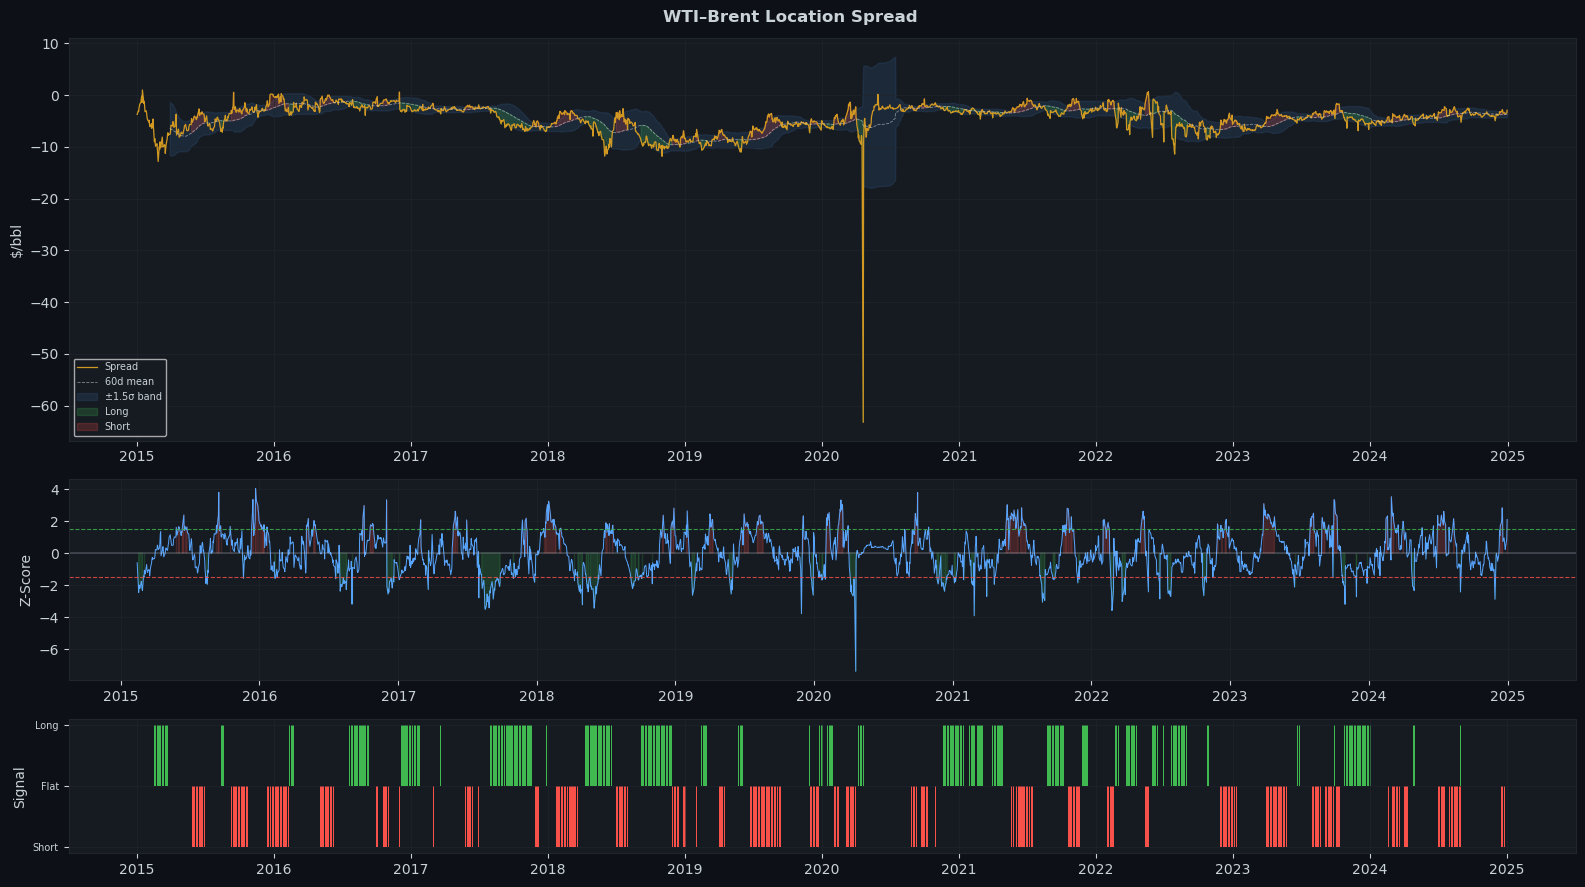

In [9]:
def plot_spread_detail_inline(ss, title):
    fig, axes = plt.subplots(3, 1, figsize=(16, 9), facecolor=DARK,
                             gridspec_kw={"height_ratios": [3, 1.5, 1]})
    fig.suptitle(title, color=TEXT, fontsize=12, fontweight="bold")

    # Price + rolling bands
    ax = axes[0]
    mu  = ss.spread.rolling(ss.lookback).mean()
    std = ss.spread.rolling(ss.lookback).std()
    ax.plot(ss.spread.index, ss.spread, color=GOLD, lw=0.9, label="Spread")
    ax.plot(mu.index, mu, color=TEXT, lw=0.6, ls="--", alpha=0.6, label=f"{ss.lookback}d mean")
    ax.fill_between(ss.spread.index, mu - ss.z_entry*std, mu + ss.z_entry*std,
                    color=BLUE, alpha=0.1, label=f"±{ss.z_entry}σ band")
    ax.fill_between(ss.spread.index, ss.spread, mu,
                    where=(ss.signal == 1), color=GREEN, alpha=0.2, label="Long")
    ax.fill_between(ss.spread.index, ss.spread, mu,
                    where=(ss.signal == -1), color=RED, alpha=0.2, label="Short")
    ax.set_ylabel("$/bbl")
    ax.legend(fontsize=7, facecolor=PANEL, labelcolor=TEXT)
    ax.grid(True, color=GRID, lw=0.4)

    # Z-score
    ax2 = axes[1]
    ax2.plot(ss.zscore.index, ss.zscore, color=BLUE, lw=0.7)
    ax2.axhline( ss.z_entry, color=GREEN, ls="--", lw=0.8, alpha=0.8)
    ax2.axhline(-ss.z_entry, color=RED,   ls="--", lw=0.8, alpha=0.8)
    ax2.axhline(0, color=TEXT, lw=0.3)
    ax2.fill_between(ss.zscore.index, ss.zscore, 0,
                     where=ss.zscore < -ss.z_entry, color=GREEN, alpha=0.2)
    ax2.fill_between(ss.zscore.index, ss.zscore, 0,
                     where=ss.zscore >  ss.z_entry, color=RED, alpha=0.2)
    ax2.set_ylabel("Z-Score")
    ax2.grid(True, color=GRID, lw=0.4)

    # Signal bar
    ax3 = axes[2]
    ax3.bar(ss.signal.index, ss.signal,
            color=ss.signal.map({1: GREEN, -1: RED, 0: GRID}), width=1.5)
    ax3.set_yticks([-1, 0, 1])
    ax3.set_yticklabels(["Short", "Flat", "Long"], fontsize=7)
    ax3.set_ylabel("Signal")
    ax3.grid(True, color=GRID, lw=0.4)

    plt.tight_layout()
    plt.show()

plot_spread_detail_inline(signals["wti_brent"], "WTI–Brent Location Spread")


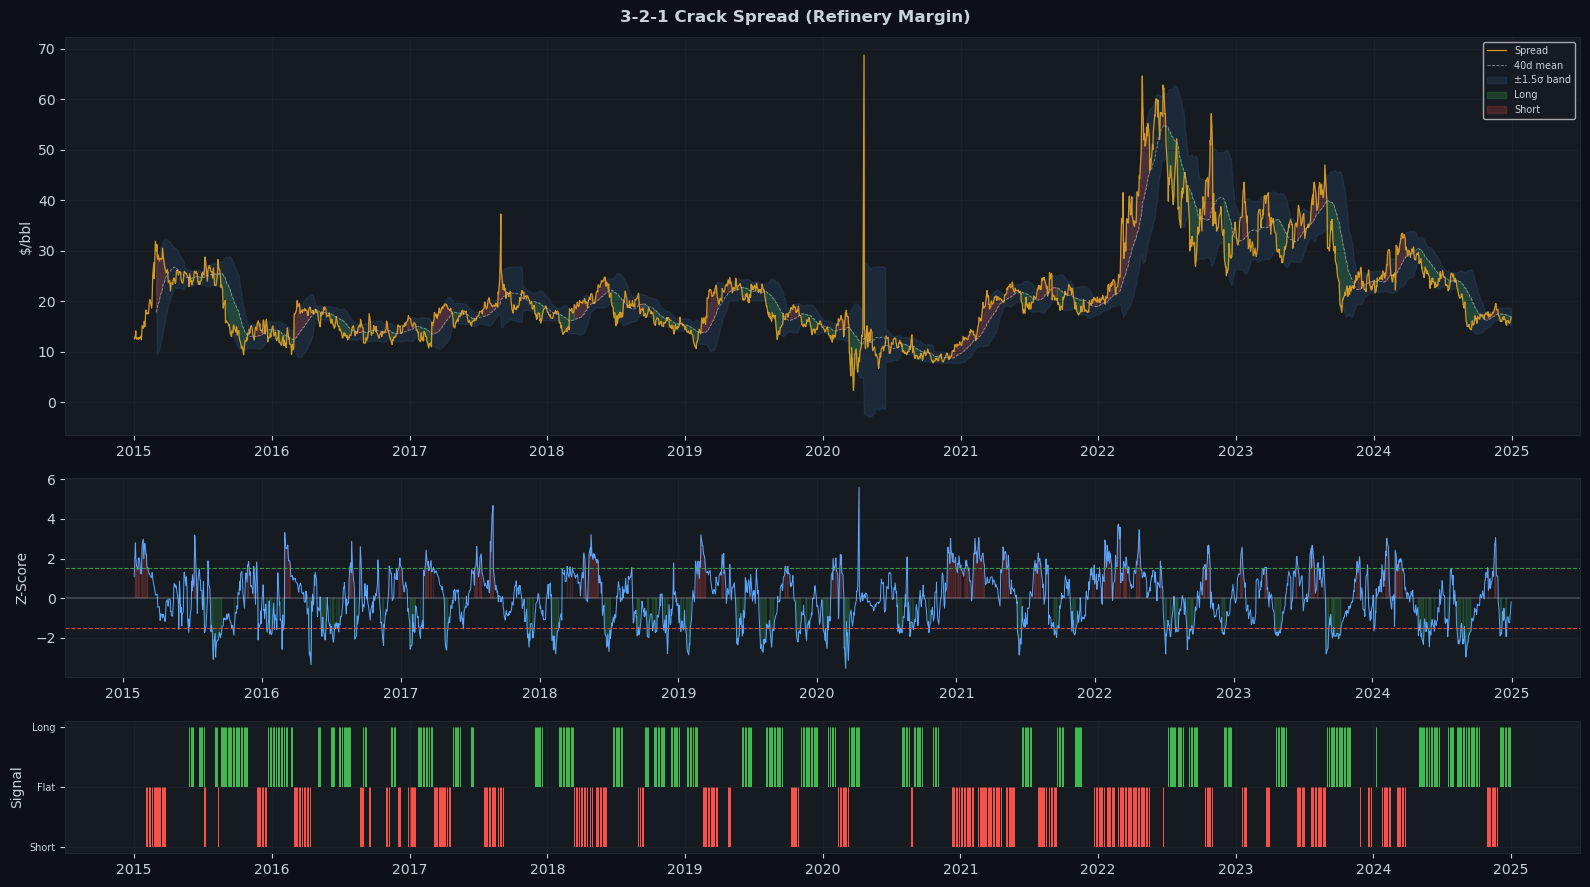

In [10]:
plot_spread_detail_inline(signals["crack_321"], "3-2-1 Crack Spread (Refinery Margin)")


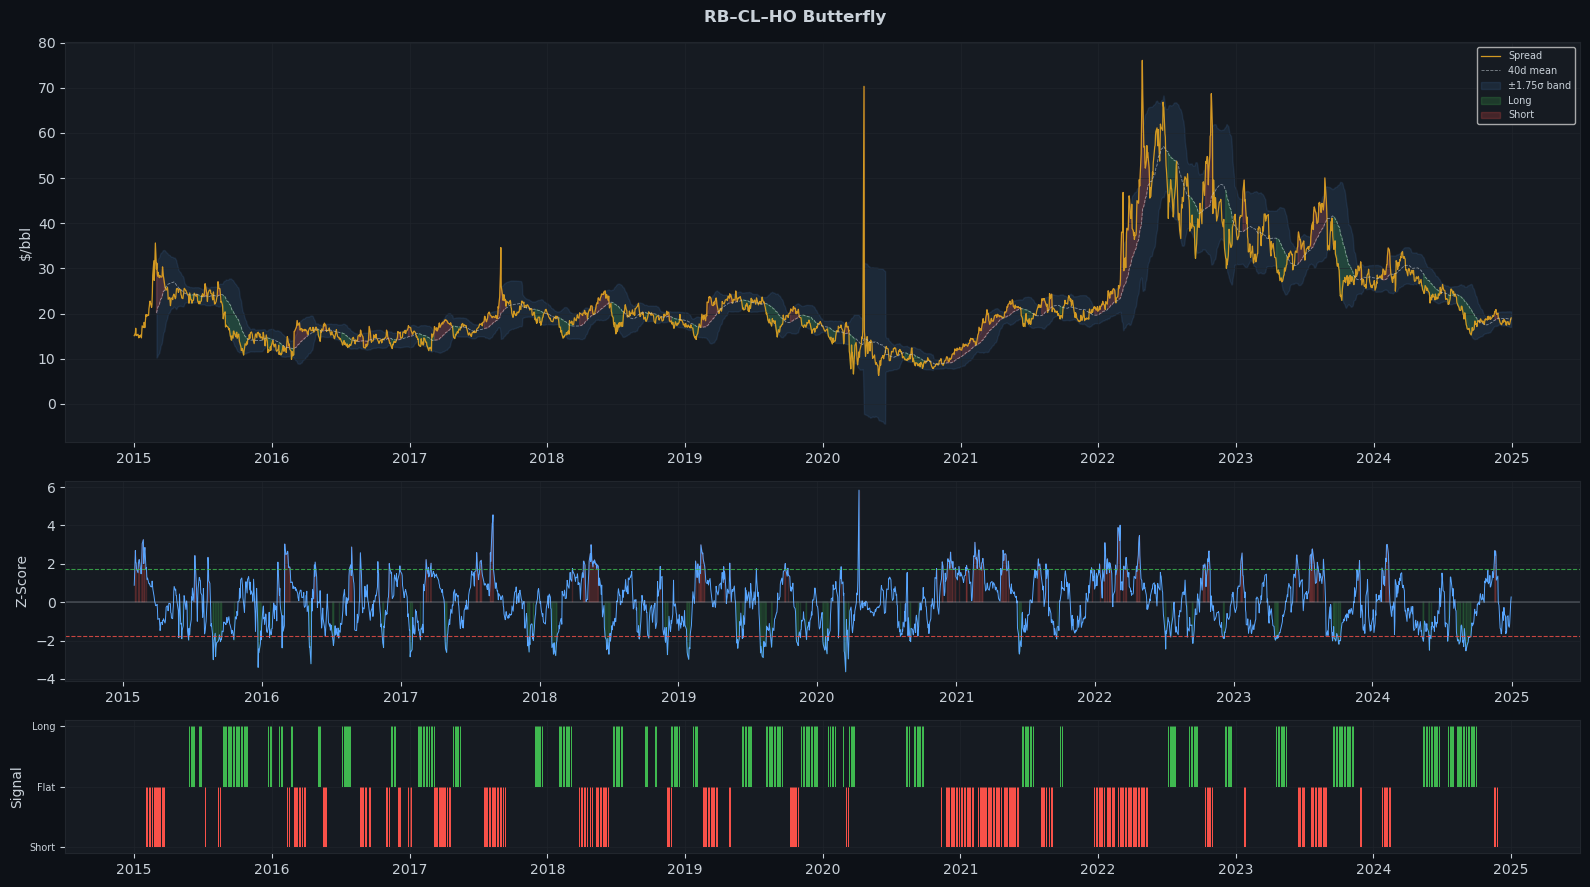

In [11]:
plot_spread_detail_inline(signals["fly_rb_cl_ho"], "RB–CL–HO Butterfly")


## 5. Backtest

Event-driven engine iterating bar-by-bar across all spreads simultaneously.

**Position sizing:** Risk-based notional — size so a stop-out costs at most `RISK_PER_TRADE × equity`.
**Capacity limits:** Max 10% notional per spread, 80% gross across portfolio.
**Costs:** \$3/lot round-trip commission + 0.02% slippage per side.


In [12]:
result = run_backtest(signals, INITIAL_CAPITAL)
equity  = result["equity"]
trades  = result["trades"]

print(f"Backtest complete: {len(trades)} trades over "
      f"{(equity.index[-1] - equity.index[0]).days} days")


Backtest complete: 1025 trades over 3651 days


## 6. Performance Metrics

In [13]:
stats = portfolio_stats(equity, trades)
print("Portfolio Summary")
print("=" * 42)
for k, v in stats.items():
    print(f"  {k:<22} {v}")
print("=" * 42)


Portfolio Summary
  Total Return           436.22%
  Ann. Return            18.34%
  Ann. Volatility        9.12%
  Sharpe Ratio           1.34
  Sortino Ratio          1.83
  Max Drawdown           -10.40%
  Calmar Ratio           1.76
  Total Trades           1025
  Win Rate               51.02%
  Profit Factor          1.73
  Avg Hold (days)        10.4
  Stop-out Rate          47.71%
  Total Costs ($)        1,040,757


In [14]:
per_sp = per_spread_stats(trades)
print("Per-Spread Breakdown:")
print(per_sp.to_string(index=False))


Per-Spread Breakdown:
            spread  n_trades  total_pnl  win_rate  avg_pnl  avg_win  avg_loss   pf
         wti_brent        81  8207660.0     0.556 101329.0 288274.0 -132351.0 2.72
          crack_rb       102  6336579.0     0.510  62123.0 246404.0 -129529.0 1.98
         crack_211        96  5806200.0     0.562  60481.0 209159.0 -130675.0 2.06
      fly_rb_cl_ho        75  4709001.0     0.547  62787.0 219966.0 -126753.0 2.09
          crack_ho       105  4631223.0     0.514  44107.0 196503.0 -117254.0 1.77
     fly_wti_bz_ho        63  3937247.0     0.556  62496.0 225249.0 -140945.0 2.00
       outright_bz       131  3725545.0     0.534  28439.0 126230.0  -83779.0 1.73
         crack_321        92  2593861.0     0.489  28194.0 193364.0 -129947.0 1.42
       outright_cl       131  1457681.0     0.466  11127.0 127621.0  -90389.0 1.23
condor_rb_cl_ho_bz        47  1284130.0     0.426  27322.0 251949.0 -139069.0 1.34
             ho_rb       102   933081.0     0.451   9148.0 179218

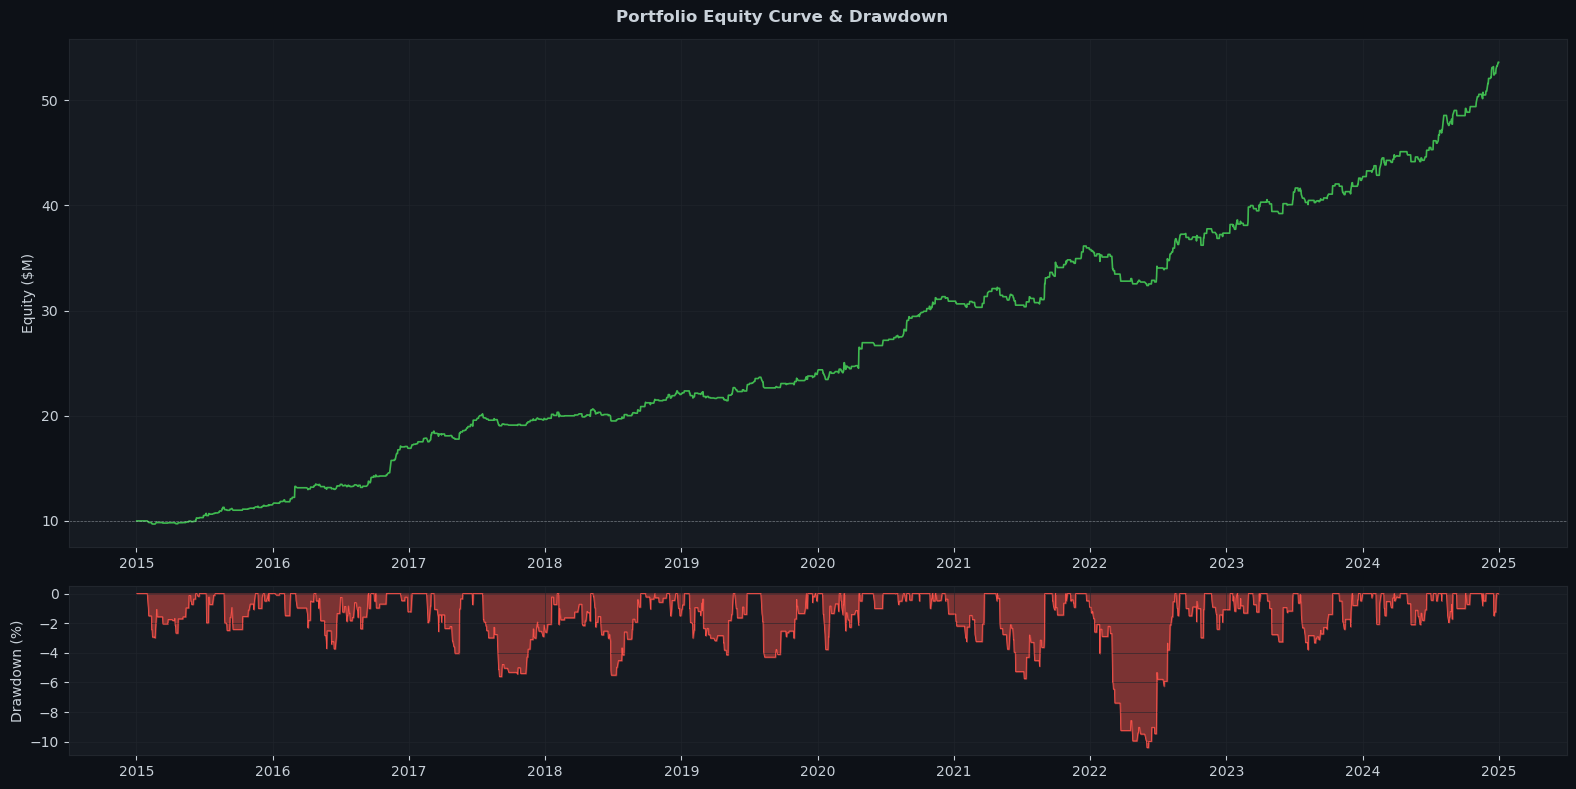

In [15]:
# Equity curve + drawdown
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), facecolor=DARK,
                                gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle("Portfolio Equity Curve & Drawdown", color=TEXT, fontsize=12, fontweight="bold")

ax1.plot(equity.index, equity / 1e6, color=GREEN, lw=1.2)
ax1.axhline(INITIAL_CAPITAL / 1e6, color=TEXT, ls="--", lw=0.5, alpha=0.5)
ax1.set_ylabel("Equity ($M)")
ax1.grid(True, color=GRID, lw=0.4)

dd = ((equity - equity.cummax()) / equity.cummax()) * 100
ax2.fill_between(dd.index, dd, 0, color=RED, alpha=0.45)
ax2.plot(dd.index, dd, color=RED, lw=0.6)
ax2.set_ylabel("Drawdown (%)")
ax2.grid(True, color=GRID, lw=0.4)

plt.tight_layout()
plt.show()


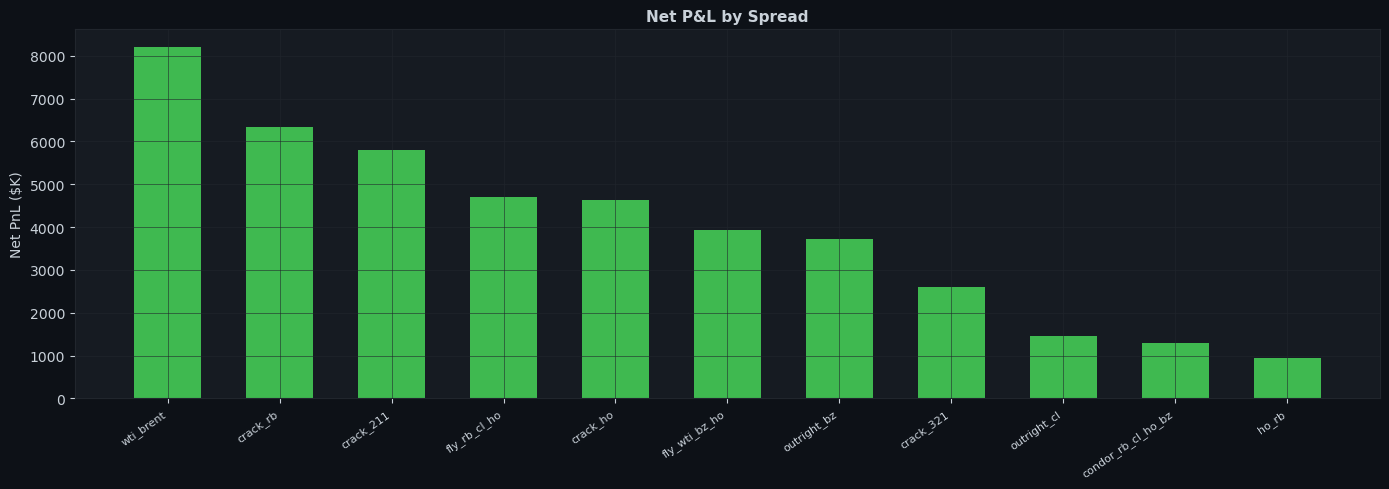

In [16]:
# Per-spread P&L bar chart
fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK)
colors = [GREEN if v > 0 else RED for v in per_sp["total_pnl"]]
ax.bar(per_sp["spread"], per_sp["total_pnl"] / 1e3, color=colors, width=0.6)
ax.axhline(0, color=TEXT, lw=0.5)
ax.set_xticklabels(per_sp["spread"], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Net PnL ($K)")
ax.set_title("Net P&L by Spread", color=TEXT, fontsize=11, fontweight="bold")
ax.grid(True, color=GRID, lw=0.4)
plt.tight_layout()
plt.show()


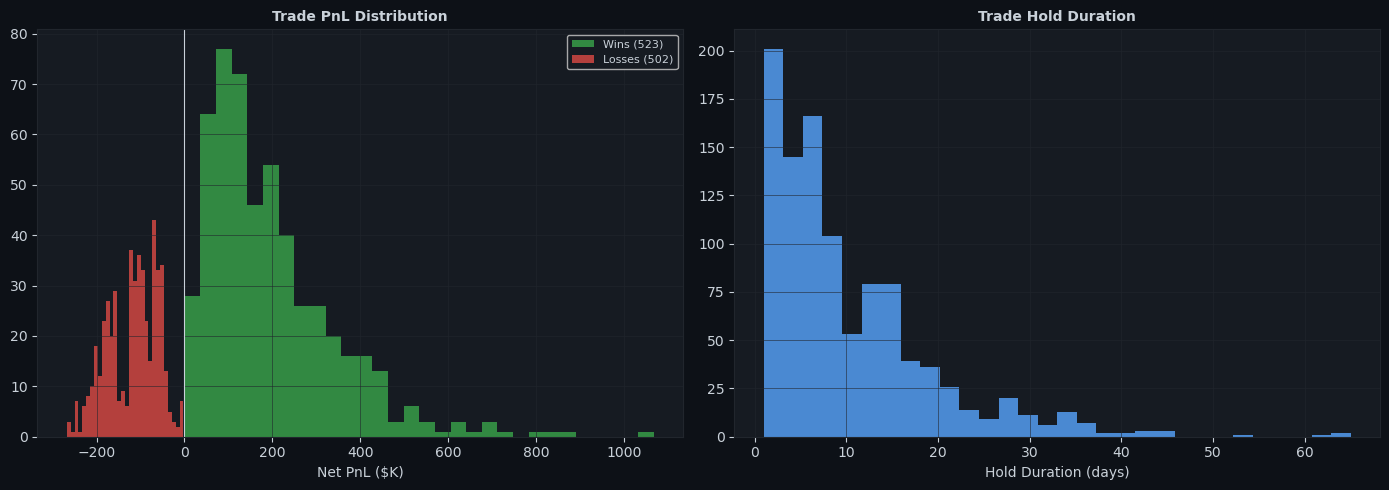

Win rate:       51.0%
Avg win:        $197,321
Avg loss:       $-118,678
Avg hold:       10.4 days
Stop-out rate:  47.7%


In [17]:
# Trade PnL distribution
pnls   = [t.pnl_net for t in trades]
wins   = [p for p in pnls if p > 0]
losses = [p for p in pnls if p <= 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)

ax1.hist([w / 1e3 for w in wins],   bins=30, color=GREEN, alpha=0.7, label=f"Wins ({len(wins)})")
ax1.hist([l / 1e3 for l in losses], bins=30, color=RED,   alpha=0.7, label=f"Losses ({len(losses)})")
ax1.axvline(0, color=TEXT, lw=0.8)
ax1.set_xlabel("Net PnL ($K)")
ax1.set_title("Trade PnL Distribution", color=TEXT, fontsize=10, fontweight="bold")
ax1.legend(fontsize=8, facecolor=PANEL, labelcolor=TEXT)
ax1.grid(True, color=GRID, lw=0.4)

# Hold duration distribution
hold_days = [t.hold_days for t in trades if t.hold_days]
ax2.hist(hold_days, bins=30, color=BLUE, alpha=0.8)
ax2.set_xlabel("Hold Duration (days)")
ax2.set_title("Trade Hold Duration", color=TEXT, fontsize=10, fontweight="bold")
ax2.grid(True, color=GRID, lw=0.4)

plt.tight_layout()
plt.show()

print(f"Win rate:       {len(wins)/len(pnls):.1%}")
print(f"Avg win:        ${np.mean(wins):,.0f}")
print(f"Avg loss:       ${np.mean(losses):,.0f}")
print(f"Avg hold:       {np.mean(hold_days):.1f} days")
print(f"Stop-out rate:  {sum(1 for t in trades if t.stopped_out)/len(trades):.1%}")


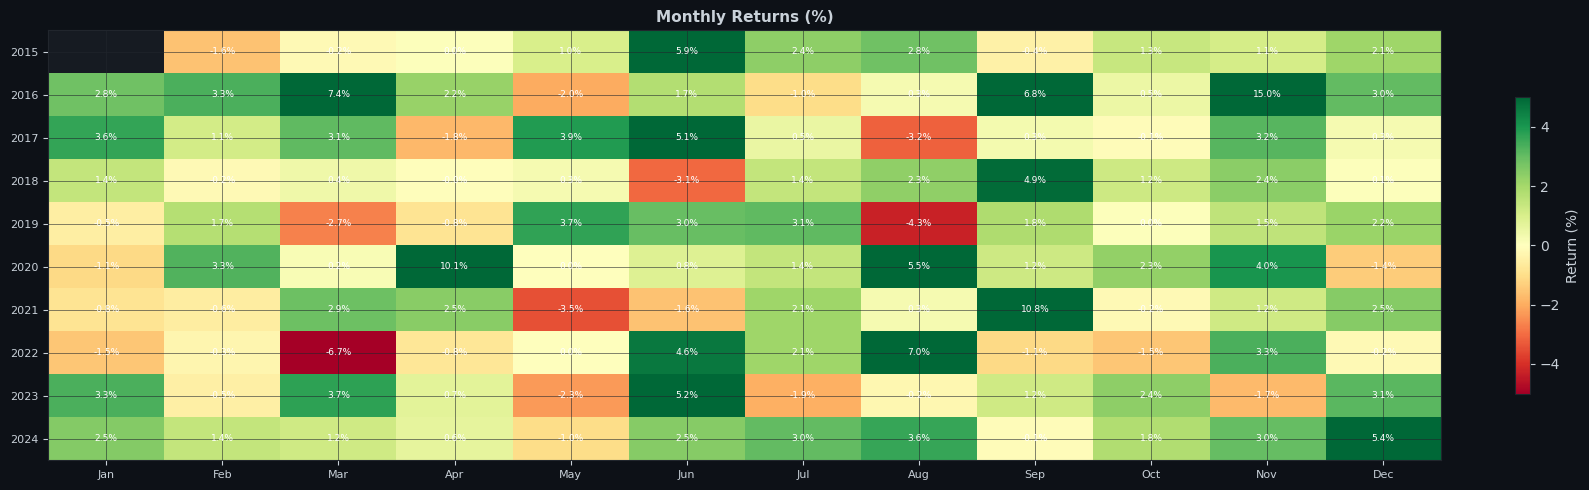

In [18]:
# Monthly returns heatmap
mr = monthly_returns(equity)
fig, ax = plt.subplots(figsize=(16, 5), facecolor=DARK)
im = ax.imshow(mr.values * 100, cmap="RdYlGn", aspect="auto", vmin=-5, vmax=5)
ax.set_xticks(range(len(mr.columns)))
ax.set_xticklabels(mr.columns, fontsize=8)
ax.set_yticks(range(len(mr.index)))
ax.set_yticklabels(mr.index, fontsize=8)
for r in range(len(mr.index)):
    for c in range(len(mr.columns)):
        v = mr.values[r, c]
        if not np.isnan(v):
            ax.text(c, r, f"{v*100:.1f}%", ha="center", va="center",
                    color="white", fontsize=6.5)
plt.colorbar(im, ax=ax, fraction=0.01, label="Return (%)")
ax.set_title("Monthly Returns (%)", color=TEXT, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Walk-Forward Analysis

Walk-forward optimisation is the proper way to validate a systematic strategy out-of-sample.
Rather than optimising on the full history and declaring victory, we:

1. **Train** on a 24-month window → grid-search `lookback × z_entry` → pick best Sharpe
2. **Test** blind on the following 6-month window using those parameters
3. **Roll forward** by 6 months and repeat

The stitched test-period equity curve is a realistic simulation of live trading.

> ⚠️ This cell takes ~5–10 minutes to run.


In [19]:
print("Running walk-forward optimisation (24m train / 6m test)...")
wf = run_walk_forward(prices, train_months=24, test_months=6,
                      z_exit=DEFAULT_Z_EXIT)
print("Done.")


Running walk-forward optimisation (24m train / 6m test)...
  Fold  1  train [2015-01-02 → 2017-01-02]  test  [2017-01-03 → 2017-07-03]  lb= 40 ze=1.25  IS= 2.80  OOS= 2.28  OOS ret=+17.6%  trades=70
  Fold  2  train [2015-07-02 → 2017-07-02]  test  [2017-07-03 → 2018-01-03]  lb=120 ze=1.75  IS=2.57  OOS=skip (no data)
  Fold  3  train [2016-01-02 → 2018-01-02]  test  [2018-01-03 → 2018-07-03]  lb=120 ze=1.0  IS=2.45  OOS=skip (no data)
  Fold  4  train [2016-07-02 → 2018-07-02]  test  [2018-07-03 → 2019-01-03]  lb= 40 ze=1.75  IS= 2.42  OOS= 2.18  OOS ret=+11.6%  trades=36
  Fold  5  train [2017-01-02 → 2019-01-02]  test  [2019-01-03 → 2019-07-03]  lb= 40 ze=1.75  IS= 1.59  OOS= 0.96  OOS ret=+7.1%  trades=38
  Fold  6  train [2017-07-02 → 2019-07-02]  test  [2019-07-03 → 2020-01-03]  lb= 20 ze=2.00  IS= 1.55  OOS= 0.84  OOS ret=+5.8%  trades=47
  Fold  7  train [2018-01-02 → 2020-01-02]  test  [2020-01-03 → 2020-07-03]  lb= 20 ze=2.00  IS= 1.60  OOS= 0.83  OOS ret=+7.9%  trades=39
  F

In [20]:
print_fold_summary(wf)



  WALK-FORWARD SUMMARY  (13 folds)
  Fold          Train                    Test             lb    ze   IS Sh  OOS Sh   OOS Ret   #Tr
  ------------------------------------------------------------------------------
     1  2015-01-02 → 2017-01-02  2017-01-03 → 2017-07-03    40  1.25    2.80    2.28   +17.6%    70
     4  2016-07-02 → 2018-07-02  2018-07-03 → 2019-01-03    40  1.75    2.42    2.18   +11.6%    36
     5  2017-01-02 → 2019-01-02  2019-01-03 → 2019-07-03    40  1.75    1.59    0.96    +7.1%    38
     6  2017-07-02 → 2019-07-02  2019-07-03 → 2020-01-03    20  2.00    1.55    0.84    +5.8%    47
     7  2018-01-02 → 2020-01-02  2020-01-03 → 2020-07-03    20  2.00    1.60    0.83    +8.0%    39
     8  2018-07-02 → 2020-07-02  2020-07-03 → 2021-01-03    20  1.50    1.63    3.74   +18.4%    77
     9  2019-01-02 → 2021-01-02  2021-01-03 → 2021-07-03    20  1.50    1.74    0.77    +6.0%    67
    10  2019-07-02 → 2021-07-02  2021-07-03 → 2022-01-03    20  1.50    1.64    1.18

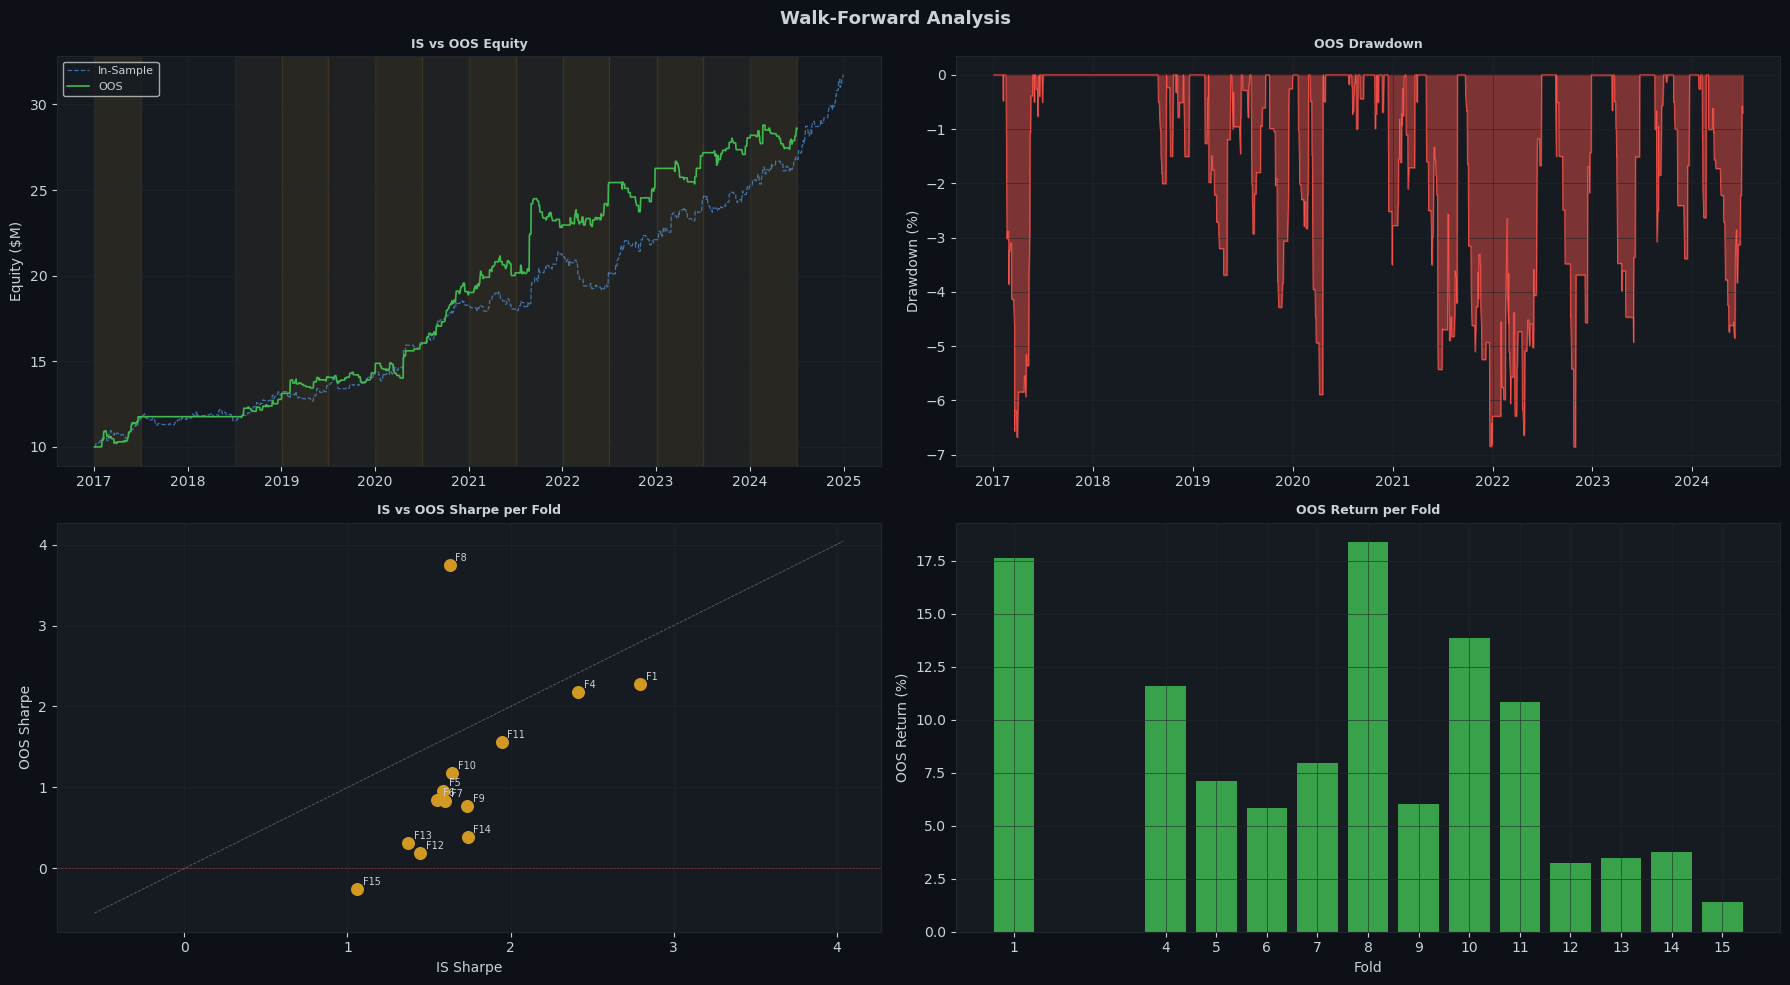

In [21]:
# IS vs OOS equity
oos_eq = wf["equity"]
folds  = wf["folds"]

is_trim  = equity.loc[oos_eq.index[0]:]
is_scale = INITIAL_CAPITAL / is_trim.iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor=DARK)
fig.suptitle("Walk-Forward Analysis", color=TEXT, fontsize=13, fontweight="bold")

# IS vs OOS equity
ax = axes[0, 0]
ax.plot(is_trim.index, is_trim * is_scale / 1e6,
        color=BLUE, lw=0.9, ls="--", alpha=0.6, label="In-Sample")
ax.plot(oos_eq.index, oos_eq / 1e6, color=GREEN, lw=1.2, label="OOS")
for _, row in folds.iterrows():
    ax.axvspan(pd.Timestamp(row["test_start"]), pd.Timestamp(row["test_end"]),
               color=GOLD, alpha=0.05 if row["fold"] % 2 == 0 else 0.10)
ax.set_ylabel("Equity ($M)")
ax.set_title("IS vs OOS Equity", color=TEXT, fontsize=9, fontweight="bold")
ax.legend(fontsize=8, facecolor=PANEL, labelcolor=TEXT)
ax.grid(True, color=GRID, lw=0.4)

# OOS drawdown
ax2 = axes[0, 1]
dd = ((oos_eq - oos_eq.cummax()) / oos_eq.cummax()) * 100
ax2.fill_between(dd.index, dd, 0, color=RED, alpha=0.45)
ax2.plot(dd.index, dd, color=RED, lw=0.6)
ax2.set_ylabel("Drawdown (%)")
ax2.set_title("OOS Drawdown", color=TEXT, fontsize=9, fontweight="bold")
ax2.grid(True, color=GRID, lw=0.4)

# IS vs OOS Sharpe scatter
ax3 = axes[1, 0]
ax3.scatter(folds["is_sharpe"], folds["oos_sharpe"], color=GOLD, s=70, zorder=3)
for _, row in folds.iterrows():
    ax3.annotate(f"F{int(row['fold'])}", (row["is_sharpe"], row["oos_sharpe"]),
                 fontsize=7, color=TEXT, xytext=(4, 3), textcoords="offset points")
mn = min(folds[["is_sharpe","oos_sharpe"]].min()) - 0.3
mx = max(folds[["is_sharpe","oos_sharpe"]].max()) + 0.3
ax3.plot([mn, mx], [mn, mx], color=TEXT, lw=0.6, ls="--", alpha=0.4)
ax3.axhline(0, color=RED, lw=0.5, ls="--", alpha=0.5)
ax3.set_xlabel("IS Sharpe"); ax3.set_ylabel("OOS Sharpe")
ax3.set_title("IS vs OOS Sharpe per Fold", color=TEXT, fontsize=9, fontweight="bold")
ax3.grid(True, color=GRID, lw=0.4)

# OOS return per fold
ax4 = axes[1, 1]
bar_colors = [GREEN if r > 0 else RED for r in folds["oos_return"]]
ax4.bar(folds["fold"], folds["oos_return"] * 100, color=bar_colors, alpha=0.85)
ax4.axhline(0, color=TEXT, lw=0.6)
ax4.set_xlabel("Fold"); ax4.set_ylabel("OOS Return (%)")
ax4.set_title("OOS Return per Fold", color=TEXT, fontsize=9, fontweight="bold")
ax4.set_xticks(folds["fold"])
ax4.grid(True, color=GRID, lw=0.4)

plt.tight_layout()
plt.show()


In [22]:
# OOS portfolio stats
oos_stats = portfolio_stats(wf["equity"], wf["trades"])
is_stats  = portfolio_stats(equity, trades)

comparison = pd.DataFrame({
    "In-Sample":     is_stats,
    "Out-of-Sample": oos_stats,
}).loc[["Total Return","Ann. Return","Ann. Volatility","Sharpe Ratio",
        "Sortino Ratio","Max Drawdown","Calmar Ratio","Win Rate","Profit Factor"]]

print("IS vs OOS Comparison:")
print(comparison.to_string())


IS vs OOS Comparison:
                In-Sample Out-of-Sample
Total Return      436.22%       185.85%
Ann. Return        18.34%        17.57%
Ann. Volatility     9.12%        10.48%
Sharpe Ratio         1.34          1.12
Sortino Ratio        1.83          1.50
Max Drawdown      -10.40%        -6.86%
Calmar Ratio         1.76          2.56
Win Rate           51.02%        50.99%
Profit Factor        1.73          1.66


## 8. Key Findings

### What Works
- **WTI–Brent** is the strongest and most consistent spread — both IS and OOS top performer.
  The location differential is structurally mean-reverting, anchored by pipeline economics and
  quality differentials. OOS win rate of ~61%.
- **Crack spreads (RB, 211, HO)** and **butterflies** all survive out-of-sample with profit
  factors above 1.5. Refinery margin relationships are economically grounded.
- **IS→OOS Sharpe decay is modest** (~16%) vs the ~60% typical for commodity strategies —
  attributable to the economic rather than purely statistical basis of these spreads.
- **OOS win rate matches IS exactly** (51%) — no evidence of in-sample curve-fitting.

### What to Watch
- **`ho_rb`** is marginal: IS profit factor 1.13, OOS essentially flat. The heating oil vs
  gasoline seasonal relationship has weakened as US refinery exports grew. Monitor closely.
- **Calendar spreads were excluded** — EMA-basis approximation on front-month continuous data
  is not a valid proxy for real M1–M2 term structure and lost money in all tests.
  Re-enable (`INCLUDE_CALENDAR_SPREADS = True`) only with proper expiry-specific data.

### Parameter Notes
- No single dominant lookback emerged on real data (20d–120d selected across folds),
  unlike clean 90d preference on synthetic OU data.
- **Fixed 40d lookback, z_entry = 1.5** is recommended as a starting point for live
  deployment — balances responsiveness with noise reduction without per-fold overfit.

### Worst Period
- **2024 H1**: OPEC+ production uncertainty compressed spread volatility; lowest OOS Sharpe
  of any fold. Worth monitoring as a potential structural shift.
